# EGX Volatility Forecasting

In [1]:
import os
import sys
import time
import math
import json


LOCAL_FIGS    = "/home/jovyan/work/figs"
LOCAL_RESULTS = "/home/jovyan/work/results"
os.makedirs(LOCAL_FIGS, exist_ok=True)
os.makedirs(LOCAL_RESULTS, exist_ok=True)

HDFS_BASE     = "hdfs://namenode:9000"
HDFS_CLEAN    = f"{HDFS_BASE}/egx/clean_panel.parquet"
HDFS_FEATURES = f"{HDFS_BASE}/egx/feature_panel.parquet"
HDFS_RESULTS  = f"{HDFS_BASE}/egx/results"

print(f"Python: {sys.version}")
print(f"Output figures -> {LOCAL_FIGS}")
print(f"Output results -> {LOCAL_RESULTS}")

Python: 3.11.6 | packaged by conda-forge | (main, Oct  3 2023, 10:40:35) [GCC 12.3.0]
Output figures -> /home/jovyan/work/figs
Output results -> /home/jovyan/work/results


In [2]:
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.window import Window

spark = (SparkSession.builder
    .appName("EGX_Models")
    .config("spark.driver.memory", "3g")
    .config("spark.executor.memory", "2g")
    .config("spark.sql.shuffle.partitions", "16")
    .getOrCreate())
spark.sparkContext.setLogLevel("WARN")
print(f"Spark version: {spark.version}")


Spark version: 3.5.0


## Load Feature Panel and Train/Test Split


In [3]:
feats = spark.read.parquet(HDFS_FEATURES)
print(f"Feature panel: {feats.count():,} rows")

FEATURE_COLS = [
    "vol_5d", "vol_10d", "vol_20d", "vol_60d",
    "ret_1d", "ret_5d", "ret_20d", "abs_ret_1d",
    "volume_ratio",
    "parkinson_1d", "parkinson_20d",
    "usdegp_vol_20d", "brent_vol_20d", "eem_vol_20d",
    "sector_vol_20d",
    "dow", "month_end", "is_ramadan",
]
TARGET = "target_vol_5d_fwd"
SPLIT_DATE = "2024-01-01"

train_df = feats.filter(F.col("date") <  F.lit(SPLIT_DATE))
test_df  = feats.filter(F.col("date") >= F.lit(SPLIT_DATE))
print(f"\nTrain rows: {train_df.count():,}")
print(f"Test rows:  {test_df.count():,}")

Feature panel: 88,292 rows

Train rows: 73,901
Test rows:  14,391


---
## Naive Baseline

In [4]:
from pyspark.ml.evaluation import RegressionEvaluator

baseline_test = test_df.withColumn("prediction", F.col("vol_20d"))

evaluator_rmse = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse")
evaluator_mae  = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="mae")
evaluator_r2   = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2")

baseline_rmse = evaluator_rmse.evaluate(baseline_test)
baseline_mae  = evaluator_mae.evaluate(baseline_test)
baseline_r2   = evaluator_r2.evaluate(baseline_test)

print(f"Baseline (20-day persistence):")
print(f"  RMSE = {baseline_rmse:.6f}")
print(f"  MAE  = {baseline_mae:.6f}")
print(f"  R^2  = {baseline_r2:.4f}")

results = {"Baseline (20-day persistence)": {
    "rmse": baseline_rmse, "mae": baseline_mae, "r2": baseline_r2,
    "rmse_reduction_vs_baseline": 0.0
}}

Baseline (20-day persistence):
  RMSE = 0.019775
  MAE  = 0.011244
  R^2  = -0.2231


---
## Spark MLlib Models

In [5]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor, GBTRegressor
from pyspark.ml import Pipeline

assembler = VectorAssembler(inputCols=FEATURE_COLS, outputCol="features")

def train_and_eval(model, name):
    print(f"Training: {name}")
    pipe = Pipeline(stages=[assembler, model])
    t0 = time.time()
    fitted = pipe.fit(train_df)
    train_time = time.time() - t0
    print(f"  Training time: {train_time:.1f}s")
    pred = fitted.transform(test_df)
    rmse = evaluator_rmse.evaluate(pred)
    mae  = evaluator_mae.evaluate(pred)
    r2   = evaluator_r2.evaluate(pred)
    reduction = 100 * (baseline_rmse - rmse) / baseline_rmse
    print(f"  RMSE = {rmse:.6f}  (vs baseline {baseline_rmse:.6f}, {reduction:+.1f}%)")
    print(f"  MAE  = {mae:.6f}")
    print(f"  R^2  = {r2:.4f}")
    results[name] = {"rmse": rmse, "mae": mae, "r2": r2,
                     "rmse_reduction_vs_baseline": reduction,
                     "train_time_sec": train_time}
    return fitted, pred

In [6]:
lr_model, lr_pred = train_and_eval(
    LinearRegression(labelCol=TARGET, featuresCol="features",
                     regParam=0.01, elasticNetParam=0.5, maxIter=100),
    "Linear Regression")

Training: Linear Regression
  Training time: 2.3s
  RMSE = 0.018043  (vs baseline 0.019775, +8.8%)
  MAE  = 0.010904
  R^2  = -0.0183


In [7]:
rf_model, rf_pred = train_and_eval(
    RandomForestRegressor(labelCol=TARGET, featuresCol="features",
                          numTrees=100, maxDepth=8, seed=42),
    "Random Forest")

Training: Random Forest
  Training time: 4.9s
  RMSE = 0.017325  (vs baseline 0.019775, +12.4%)
  MAE  = 0.009760
  R^2  = 0.0612


In [8]:
gbt_model, gbt_pred = train_and_eval(
    GBTRegressor(labelCol=TARGET, featuresCol="features",
                 maxIter=80,          
                 maxDepth=3,           
                 stepSize=0.05,        
                 subsamplingRate=0.8,  
                 seed=42),
    "Gradient-Boosted Trees")

Training: Gradient-Boosted Trees
  Training time: 9.8s
  RMSE = 0.016726  (vs baseline 0.019775, +15.4%)
  MAE  = 0.009698
  R^2  = 0.1251


### Feature Importances (Random Forest)

       feature  importance
    is_ramadan    0.001844
           dow    0.015046
        ret_1d    0.015494
     month_end    0.016367
  volume_ratio    0.021400
    abs_ret_1d    0.040593
   eem_vol_20d    0.043955
usdegp_vol_20d    0.044420
        ret_5d    0.046500
       ret_20d    0.048201
  parkinson_1d    0.051927
       vol_60d    0.068444
 parkinson_20d    0.077414
       vol_10d    0.084168
        vol_5d    0.086217
 brent_vol_20d    0.101021
sector_vol_20d    0.115437
       vol_20d    0.121552


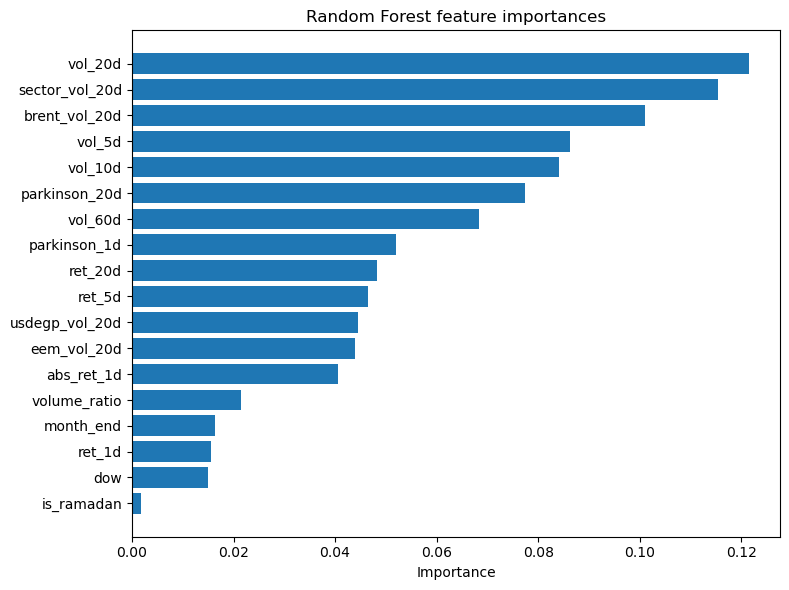

In [9]:
rf_inner = rf_model.stages[-1]
importances = rf_inner.featureImportances.toArray()
import pandas as pd
imp_df = (pd.DataFrame({"feature": FEATURE_COLS, "importance": importances})
            .sort_values("importance", ascending=True))
print(imp_df.to_string(index=False))

import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.barh(imp_df["feature"], imp_df["importance"])
plt.xlabel("Importance")
plt.title("Random Forest feature importances")
plt.tight_layout()
plt.savefig(f"{LOCAL_FIGS}/fig_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

---
## PyTorch LSTM 

In [10]:
pdf = feats.select("ticker", "sector", "date",
                   *FEATURE_COLS, TARGET).toPandas()
pdf["date"] = pd.to_datetime(pdf["date"])
pdf = pdf.sort_values(["ticker", "date"]).reset_index(drop=True)
print(f"Loaded {len(pdf):,} rows for LSTM preparation")

Loaded 88,292 rows for LSTM preparation


In [11]:
import numpy as np

SEQ_LEN = 60

train_mask = pdf["date"] <  pd.Timestamp(SPLIT_DATE)
val_mask   = (pdf["date"] >= pd.Timestamp("2023-01-01")) & (pdf["date"] <  pd.Timestamp(SPLIT_DATE))
test_mask  = pdf["date"] >= pd.Timestamp(SPLIT_DATE)
train_only = train_mask & ~val_mask

mu     = pdf.loc[train_only, FEATURE_COLS].mean()
sigma_norm = pdf.loc[train_only, FEATURE_COLS].std().replace(0, 1)
pdf[FEATURE_COLS] = (pdf[FEATURE_COLS] - mu) / sigma_norm


In [12]:
def build_sequences(df_subset):
    Xs, ys, tickers, dates = [], [], [], []
    for ticker, group in df_subset.groupby("ticker", sort=False):
        g = group.reset_index(drop=True)
        if len(g) < SEQ_LEN:
            continue
        feat_arr = g[FEATURE_COLS].to_numpy(dtype=np.float32)
        targ_arr = g[TARGET].to_numpy(dtype=np.float32)
        for i in range(SEQ_LEN - 1, len(g)):
            Xs.append(feat_arr[i - SEQ_LEN + 1: i + 1])
            ys.append(targ_arr[i])
            tickers.append(ticker)
            dates.append(g.loc[i, "date"])
    return (np.stack(Xs), np.array(ys, dtype=np.float32),
            np.array(tickers), np.array(dates))

print("building sequences")
X_tr, y_tr, _, _    = build_sequences(pdf[train_only])
X_val, y_val, _, _  = build_sequences(pdf[val_mask])
X_te, y_te, te_tk, te_dt = build_sequences(pdf[test_mask | val_mask])
te_keep = pd.Series(te_dt) >= pd.Timestamp(SPLIT_DATE)
X_te, y_te, te_tk, te_dt = X_te[te_keep], y_te[te_keep], te_tk[te_keep], te_dt[te_keep]

print(f"  X_train: {X_tr.shape}, y_train: {y_tr.shape}")
print(f"  X_val:   {X_val.shape}, y_val:   {y_val.shape}")
print(f"  X_test:  {X_te.shape}, y_test:  {y_te.shape}")

building sequences
  X_train: (65819, 60, 18), y_train: (65819,)
  X_val:   (4188, 60, 18), y_val:   (4188,)
  X_test:  (14391, 60, 18), y_test:  (14391,)


In [13]:
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import torch
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


In [14]:
class VolLSTM(nn.Module):
    def __init__(self, n_features, hidden_dim=64, num_layers=2, dropout=0.2):
        super().__init__()
        self.lstm = nn.LSTM(input_size=n_features, hidden_size=hidden_dim,
                            num_layers=num_layers, batch_first=True,
                            dropout=dropout if num_layers > 1 else 0.0)
        self.head = nn.Sequential(
            nn.Linear(hidden_dim, 32), nn.ReLU(),
            nn.Dropout(dropout), nn.Linear(32, 1))

    def forward(self, x):
        out, _ = self.lstm(x)
        return self.head(out[:, -1, :]).squeeze(-1)

In [15]:
torch.manual_seed(42)
model = VolLSTM(n_features=len(FEATURE_COLS)).to(DEVICE)
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters()):,}")

Trainable parameters: 56,897


In [16]:
def to_tensor_dataset(X, y):
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

train_loader = DataLoader(to_tensor_dataset(X_tr, y_tr), batch_size=256, shuffle=True)
val_loader   = DataLoader(to_tensor_dataset(X_val, y_val), batch_size=512, shuffle=False)
test_loader  = DataLoader(to_tensor_dataset(X_te, y_te), batch_size=512, shuffle=False)


optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()


def evaluate(loader):
    model.eval()
    losses, preds, trues = [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            p = model(xb)
            losses.append(loss_fn(p, yb).item() * len(yb))
            preds.append(p.cpu().numpy())
            trues.append(yb.cpu().numpy())
    n = sum(len(t) for t in trues)
    rmse = math.sqrt(sum(losses) / n)
    return rmse, np.concatenate(preds), np.concatenate(trues)


In [17]:
EPOCHS, PATIENCE = 30, 5
best_val, patience_left, best_state = float("inf"), PATIENCE, None
history = []
t0 = time.time()

for epoch in range(1, EPOCHS + 1):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = loss_fn(model(xb), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        train_losses.append(loss.item() * len(yb))
    train_rmse = math.sqrt(sum(train_losses) / len(train_loader.dataset))
    val_rmse, _, _ = evaluate(val_loader)
    history.append({"epoch": epoch, "train_rmse": train_rmse, "val_rmse": val_rmse})
    print(f"Epoch {epoch:2d}  train RMSE={train_rmse:.6f}  val RMSE={val_rmse:.6f}")
    if val_rmse < best_val - 1e-6:
        best_val, best_state, patience_left = val_rmse, {k: v.clone() for k,v in model.state_dict().items()}, PATIENCE
    else:
        patience_left -= 1
        if patience_left == 0:
            print(f"  Early stopping at epoch {epoch} (best val RMSE = {best_val:.6f})")
            break
lstm_train_time = time.time() - t0
print(f"\nLSTM total training time: {lstm_train_time:.1f}s")
if best_state is not None:
    model.load_state_dict(best_state)

Epoch  1  train RMSE=0.030937  val RMSE=0.014898
Epoch  2  train RMSE=0.026205  val RMSE=0.014846
Epoch  3  train RMSE=0.025561  val RMSE=0.014869
Epoch  4  train RMSE=0.024937  val RMSE=0.014776
Epoch  5  train RMSE=0.024721  val RMSE=0.014752
Epoch  6  train RMSE=0.024664  val RMSE=0.014784
Epoch  7  train RMSE=0.024500  val RMSE=0.014709
Epoch  8  train RMSE=0.023869  val RMSE=0.014739
Epoch  9  train RMSE=0.024393  val RMSE=0.014599
Epoch 10  train RMSE=0.021191  val RMSE=0.014816
Epoch 11  train RMSE=0.024901  val RMSE=0.014914
Epoch 12  train RMSE=0.024755  val RMSE=0.015572
Epoch 13  train RMSE=0.020747  val RMSE=0.014817
Epoch 14  train RMSE=0.017967  val RMSE=0.014940
  Early stopping at epoch 14 (best val RMSE = 0.014599)

LSTM total training time: 158.5s


In [18]:
lstm_rmse, lstm_preds, lstm_trues = evaluate(test_loader)
lstm_mae = float(np.mean(np.abs(lstm_preds - lstm_trues)))
ss_res = float(np.sum((lstm_trues - lstm_preds) ** 2))
ss_tot = float(np.sum((lstm_trues - lstm_trues.mean()) ** 2))
lstm_r2 = 1.0 - ss_res / ss_tot
reduction = 100 * (baseline_rmse - lstm_rmse) / baseline_rmse
print(f"LSTM:  RMSE = {lstm_rmse:.6f}  ({reduction:+.1f}% vs baseline)")
print(f"       MAE  = {lstm_mae:.6f}")
print(f"       R^2  = {lstm_r2:.4f}")

results["LSTM"] = {"rmse": lstm_rmse, "mae": lstm_mae, "r2": lstm_r2,
                   "rmse_reduction_vs_baseline": reduction,
                   "train_time_sec": lstm_train_time}

lstm_test_pdf = pd.DataFrame({"ticker": te_tk, "date": te_dt,
                              "y_true": lstm_trues, "y_pred": lstm_preds})
lstm_test_pdf.to_csv(f"{LOCAL_RESULTS}/lstm_test_predictions.csv", index=False)

LSTM:  RMSE = 0.016170  (+18.2% vs baseline)
       MAE  = 0.009583
       R^2  = 0.1822


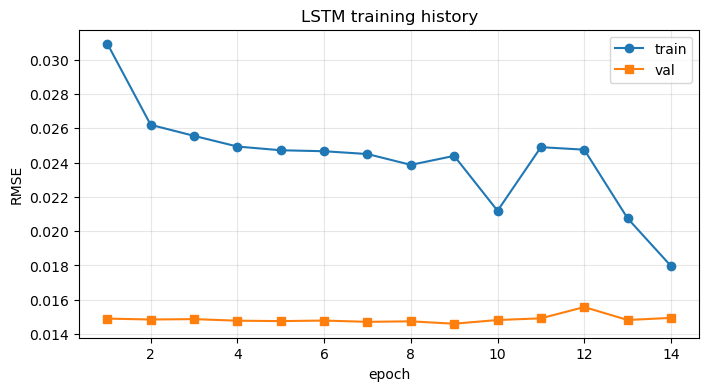

In [19]:
# Training history plot
hist_df = pd.DataFrame(history)
plt.figure(figsize=(8, 4))
plt.plot(hist_df["epoch"], hist_df["train_rmse"], label="train", marker="o")
plt.plot(hist_df["epoch"], hist_df["val_rmse"], label="val", marker="s")
plt.xlabel("epoch"); plt.ylabel("RMSE"); plt.title("LSTM training history")
plt.legend(); plt.grid(alpha=0.3)
plt.savefig(f"{LOCAL_FIGS}/fig_lstm_training.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Final Comparison Table

In [20]:
comp = pd.DataFrame(results).T
keep_cols = ["rmse", "mae", "r2", "rmse_reduction_vs_baseline"]
comp = comp[[c for c in keep_cols if c in comp.columns]]
comp.columns = ["RMSE", "MAE", "R²", "RMSE Reduction vs. Baseline (%)"]
comp = comp.round({"RMSE": 6, "MAE": 6, "R²": 4, "RMSE Reduction vs. Baseline (%)": 1})
print(comp.to_string())
comp.to_csv(f"{LOCAL_RESULTS}/table_model_comparison.csv")

                                   RMSE       MAE      R²  RMSE Reduction vs. Baseline (%)
Baseline (20-day persistence)  0.019775  0.011244 -0.2231                              0.0
Linear Regression              0.018043  0.010904 -0.0183                              8.8
Random Forest                  0.017325  0.009760  0.0612                             12.4
Gradient-Boosted Trees         0.016726  0.009698  0.1251                             15.4
LSTM                           0.016170  0.009583  0.1822                             18.2


In [21]:
gbt_pdf_check = gbt_pred.select("date", "ticker", TARGET, "prediction").toPandas()
print("Prediction stats:")
print(gbt_pdf_check["prediction"].describe())
print("\nActual stats:")
print(gbt_pdf_check[TARGET].describe())
print("\nTop 5 wildest predictions:")
print(gbt_pdf_check.nlargest(5, "prediction"))
print("\nTop 5 most negative predictions:")
print(gbt_pdf_check.nsmallest(5, "prediction"))

Prediction stats:
count    14391.000000
mean         0.020939
std          0.009350
min          0.004455
25%          0.014706
50%          0.018736
75%          0.024466
max          0.145010
Name: prediction, dtype: float64

Actual stats:
count    14391.000000
mean         0.022431
std          0.017882
min          0.000406
25%          0.011935
50%          0.018295
75%          0.027763
max          0.598172
Name: target_vol_5d_fwd, dtype: float64

Top 5 wildest predictions:
            date ticker  target_vol_5d_fwd  prediction
7015  2024-03-11   OCDI           0.080377    0.145010
7891  2024-03-19   TMGH           0.026163    0.144459
478   2024-03-20   EFIH           0.093778    0.143631
477   2024-03-19   EFIH           0.073811    0.143029
7016  2024-03-12   OCDI           0.116478    0.142148

Top 5 most negative predictions:
             date ticker  target_vol_5d_fwd  prediction
9234   2024-05-29   MFPC           0.041810    0.004455
7926   2024-05-29   TMGH           0.0